<table>
  <tr>
    <td><div align="left"><font size="30">Robotics Toolbox for Python</font></div></td>
    <td><img src="support/figs/RobToolBox_RoundLogoB.png" width="300"></td>
  </tr>
</table>

<p></p>
<div align="center" style="font-size: 1.5em;">🤖🚀 Robotics without the cruft</div>
<p></p>


(c) Peter Corke 2026

In [1]:
import importlib
import setup_tutorial
importlib.reload(setup_tutorial)
await setup_tutorial.setup_tutorial(required_toolboxes=['roboticstoolbox', 'pgraph'], required_packages=['matplotlib', 'numpy', 'scipy'])

print("\nrobotics toolbox version:", importlib.import_module("roboticstoolbox").__version__)

Setting up tutorial environment — wait for the ✅
setup_tutorial: environment=local Python
setup_tutorial: required_toolboxes=['roboticstoolbox', 'pgraph']
setup_tutorial: required_packages=['matplotlib', 'numpy', 'scipy']
setup_tutorial: toolbox 'roboticstoolbox' source=already installed in environment
setup_tutorial: toolbox 'pgraph' source=already installed in environment
✅ Setup complete — toolboxes: roboticstoolbox, pgraph; packages: matplotlib, numpy, scipy

robotics toolbox version: 1.2.0


In [2]:
# import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(linewidth=100, formatter={'float': lambda x: f"{x:8.3g}" if abs(x) > 1e-10 else f"{0:8.3g}"})

import math

# Mobile robotics

## Mobile robot kinematics

We can create a vehicle with bicycle kinematics, with a wheelbase of 2m.

In [3]:
from roboticstoolbox import Bicycle

veh = Bicycle(L=2, workspace=10)


We can find the maximum path curvature it can achieve, which is the reciprocal of the minimum turning radius.

In [4]:
print(veh.curvature_max)

3.156875757337521


The initial state of the vehicle $(x,y,\theta)$, where $\theta$ is the heading angle, can be set at contruction time but defaults to zero

In [5]:
print(veh.x)

[       0        0        0]


The state derivative $(\dot{x}, \dot{y}, \dot{\theta})$ is a function of current state and the inputs $(v, \gamma)$ where $\gamma$ is the angle of the steered wheel.

In [6]:
xd = veh.deriv(u=(1, 0.2), x= [0,0,0])
print(xd)

[       1        0    0.101]


which indicates motion in the x-direction and a change of heading angle.

The model supports simple animation of motion directed by a `control` function.  In this case the control sets a constant velocity and a steered wheel angle of 0.5 rad for $1<t<2$

In [7]:
veh.run(10, control=lambda v, t, x: (1, 0.5 if 1<t<2 else 0), animate=True)

array([[     0.1,        0,        0],
       [     0.2,        0,        0],
       [     0.3,        0,        0],
       [     0.4,        0,        0],
       [     0.5,        0,        0],
       [     0.6,        0,        0],
       [     0.7,        0,        0],
       [     0.8,        0,        0],
       [     0.9,        0,        0],
       [       1,        0,        0],
       [     1.1,        0,        0],
       [     1.2,        0,   0.0273],
       [     1.3,  0.00273,   0.0546],
       [     1.4,  0.00819,   0.0819],
       [     1.5,   0.0164,    0.109],
       [     1.6,   0.0273,    0.137],
       [     1.7,   0.0409,    0.164],
       [     1.8,   0.0572,    0.191],
       [    1.89,   0.0762,    0.219],
       [    1.99,   0.0979,    0.246],
       [    2.09,    0.122,    0.246],
       [    2.19,    0.147,    0.246],
       [    2.28,    0.171,    0.246],
       [    2.38,    0.195,    0.246],
       [    2.48,     0.22,    0.246],
       [    2.57,    0.24

## Graph-based planning

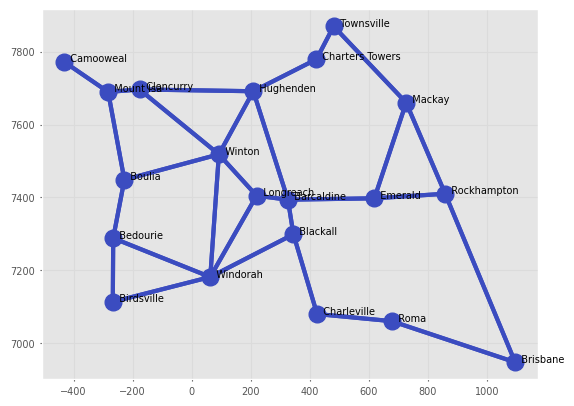

In [8]:
from pgraph import UGraph # from PGraph package
from roboticstoolbox import rtb_path_to_datafile # from Robotics Toolbox package
import json

# load an example route map from the rtb-data package
with open(rtb_path_to_datafile('data/queensland.json'), 'r') as f:
    data = json.loads(f.read())

g = UGraph() # create an undirected graph
for name, info in data['places'].items():
    g.add_vertex(name=name, coord=info["utm"]) # add places as vertices
for route in data['routes']:
    g.add_edge(route['start'], route['end'], cost=route['distance']) # add routes as edges

g.plot()

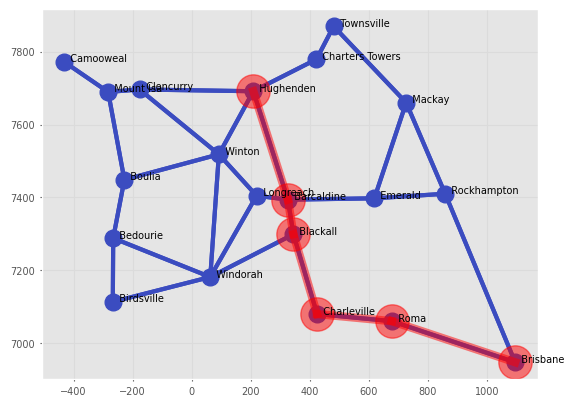

In [9]:
path, length, parents = g.path_Astar('Hughenden', 'Brisbane')

g.plot(block=None)
g.highlight_path(path)

## Occupancy grid path planning

<Axes: xlabel='x', ylabel='y'>

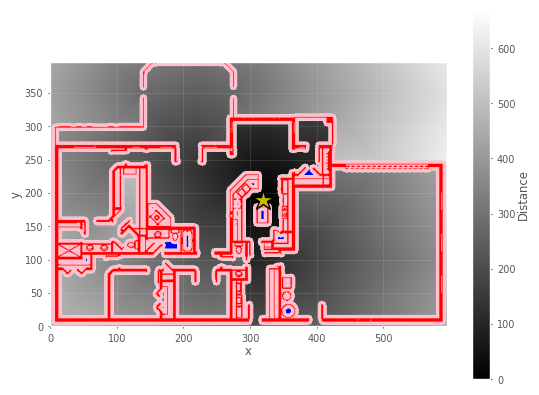

In [10]:
from roboticstoolbox import rtb_load_matfile, DistanceTransformPlanner

house = rtb_load_matfile('data/house.mat')
floorplan = house['floorplan']
places = house['places']

pmarker = dict(markersize=6, color='y')
dx = DistanceTransformPlanner(floorplan, inflate=5)
dx.plan(places.kitchen)
dx.plot()

<Axes: xlabel='x', ylabel='y'>

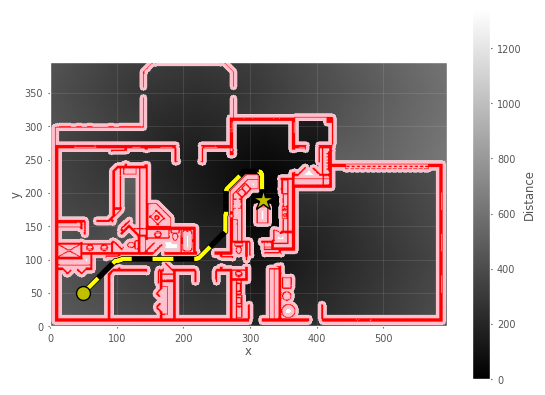

In [11]:
p = dx.query(places.br3)

dx.plot(p, inflated=True, path_marker=pmarker)

## Sample-based planning

plotted background


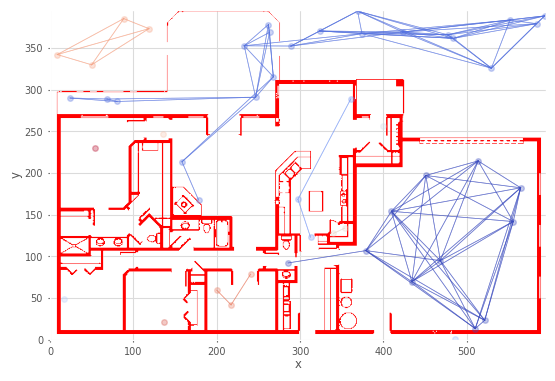

plotted roadmap
PRMPlanner: 
  BinaryOccupancyGrid: 596 x 397, cell size=1, x = [0.0, 595.0], y = [0.0, 396.0], 8.8% occupied
  UGraph: 50 vertices, 222 edges, 12 components


In [12]:
from roboticstoolbox import PRMPlanner


house = rtb_load_matfile('data/house.mat')
floorplan = house['floorplan']
places = house['places']

prm = PRMPlanner(occgrid=floorplan, seed=0)
prm.plan(npoints=50)

prm.plot(edge=dict(alpha=0.3), vertex=dict(alpha=0.3))
print(prm)

plotted background


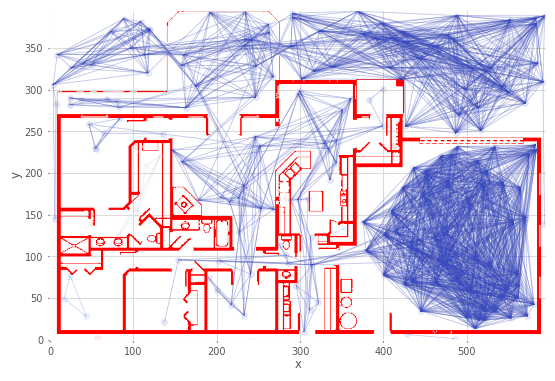

plotted roadmap
PRMPlanner: 
  BinaryOccupancyGrid: 596 x 397, cell size=1, x = [0.0, 595.0], y = [0.0, 396.0], 8.8% occupied
  UGraph: 200 vertices, 4464 edges, 14 components


In [13]:
# reseed the PRN to get a workable solution
# prm = PRMPlanner(occgrid=floorplan, seed=2)
prm.plan(npoints=200)
prm.plot(edge=dict(alpha=0.1), vertex=dict(alpha=0.1))
print(prm)

## Planning with motion constraints

### Dubbins paths

<Axes: xlabel='x', ylabel='y'>

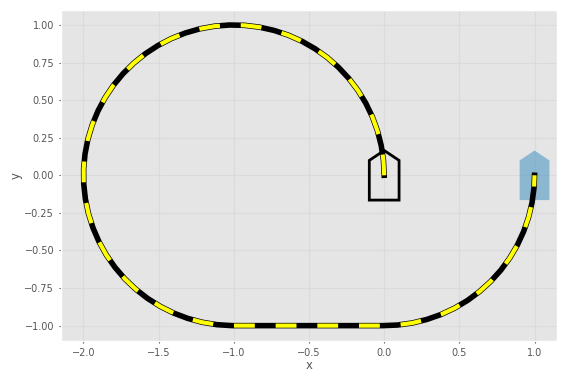

In [14]:
from roboticstoolbox import DubinsPlanner

qs = (0, 0, math.pi/2)
qg = (1, 0, math.pi/2)

dubins = DubinsPlanner(curvature=1)
path, status = dubins.query(qs, qg)

dubins.plot(path)

### Reeds-Shepp path

<Axes: xlabel='x', ylabel='y'>

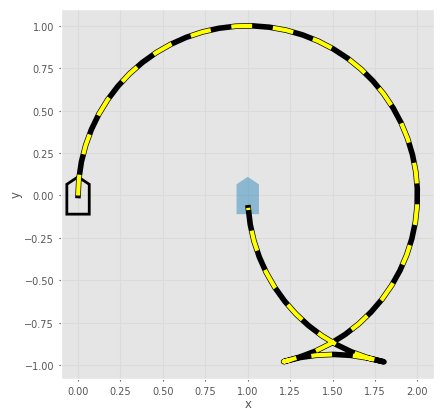

In [15]:
from roboticstoolbox import ReedsSheppPlanner

rs = ReedsSheppPlanner(curvature=1)
path, status = rs.query(qs, qg)

rs.plot(path)

### Configuration-space planning

Let's look at the classic piano mover's problem

In [16]:
from spatialmath import Polygon2
from roboticstoolbox import PolygonMap, RRTPlanner, Bicycle

# start and goal configuration
qs = (2, 8, -math.pi/2)
qg = (8, 2, -math.pi/2)

# obstacle map
map = PolygonMap(workspace=[0, 10])
map.add([(5, 50), (5, 6), (6, 6), (6, 50)])
map.add([(5, 4), (5, -50), (6, -50), (6, 4)])

# create a polygon to represent the piano
length, width  =3, 1.5
piano = Polygon2(
    np.array([(-length / 2, width / 2), (-length / 2, -width / 2), (length / 2, -width / 2), (length / 2, width / 2)]).T
)

# the piano has bicycle kinematics with a maximum steering angle of 1 radian and a wheelbase of 2m (ok, it's an odd piano)
vehicle = Bicycle(steer_max=1, L=2, polygon=piano)

rrt = RRTPlanner(map=map, vehicle=vehicle, verbose=False, npoints=50, showsamples=True, seed=0)

We'll build an RRT with its goal `qg` in the lower-right of the figure

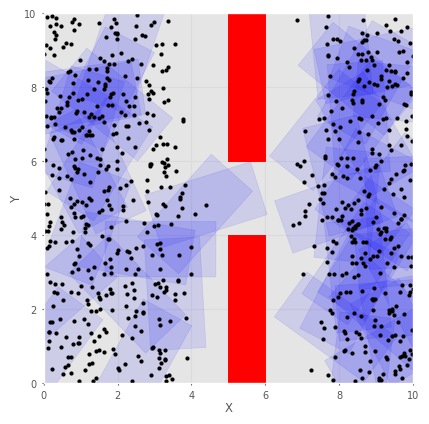

In [17]:
map.plot()
rrt.plan(goal=qg)

We have found a bunch of piano poses that don't intersect with the red obstacle, a dot represents the position $(x,y)$ and the translucent rectangle indicates its orientation.  Then we joined them up using an RRT.

Now we can query for a path to the goal, given a start pose `qs` which is in the upper left of the figure.

In [18]:
path, status = rrt.query(start=qs)
print(status)

[DVertex[#34, coord=(1.644, 7.95, -2.051)], DVertex[#25, coord=(1.52, 6.047, -2.131)], DVertex[#23, coord=(4.394, 4.813, 0.3043)], DVertex[#17, coord=(7.913, 4.707, 0.3379)], DVertex[#11, coord=(8.999, 4.479, -0.5868)], DVertex[#3, coord=(8.224, 4.8, -1.682)], DVertex[#0, coord=(8, 2, -1.571)]]
RRTStatus(length=19.543490758346646, initial_d=np.float64(0.5996466379914136), vertices=[DVertex[#34, coord=(1.644, 7.95, -2.051)], DVertex[#25, coord=(1.52, 6.047, -2.131)], DVertex[#23, coord=(4.394, 4.813, 0.3043)], DVertex[#17, coord=(7.913, 4.707, 0.3379)], DVertex[#11, coord=(8.999, 4.479, -0.5868)], DVertex[#3, coord=(8.224, 4.8, -1.682)], DVertex[#0, coord=(8, 2, -1.571)]])


A path has been found and is described by a set of RRT vertices with pose $(x,y,\theta)$.

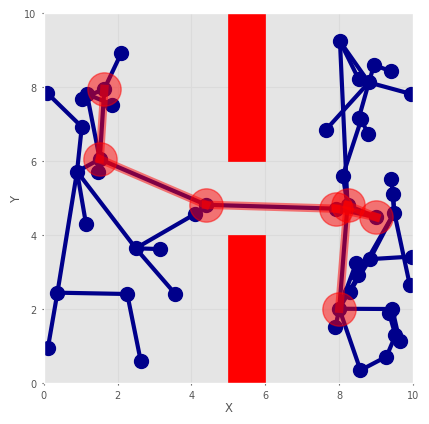

In [19]:
map.plot()
rrt.g.plot(colorcomponents=False, text=False, force2d=True,
    vopt=dict(color='darkblue', marker='o', markersize=10), 
    eopt=dict(color='darkblue', linewidth=3), block=None)
rrt.g.highlight_path(status.vertices, color='r')


The planner returns a smoothed path by fitting Dubins curves between the RRT vertices, resulting in a path that is driveable by the piano

In [20]:
with np.printoptions(threshold=20):
    print(path)

[[ 1.64427294  7.94970389 -2.05090532]
 [ 1.57019221  7.76428843 -1.85090532]
 [ 1.53442453  7.56785138 -1.65090532]
 ...
 [ 8.01359372  2.20839008 -1.65153633]
 [ 8.00003956  2.00889515 -1.5796916 ]
 [ 8.          2.         -1.57079633]]


We can overlay that on the RRT

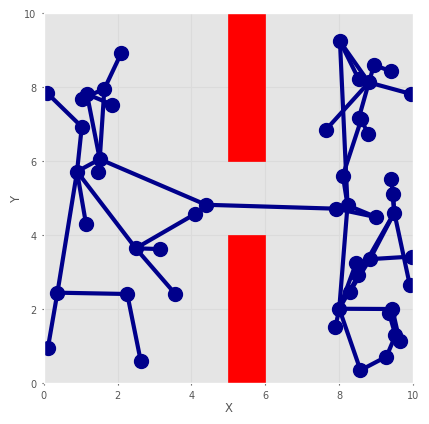

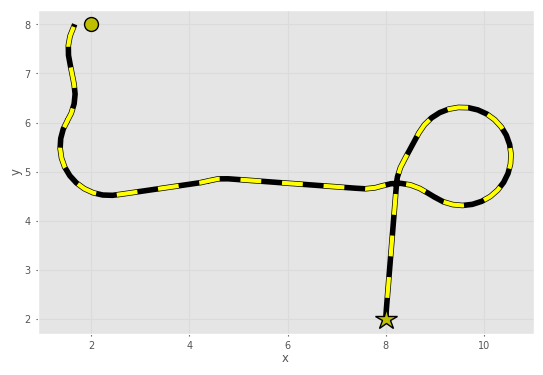

In [21]:
map.plot()
rrt.g.plot(colorcomponents=False, text=False, force2d=True,
    vopt=dict(color='darkblue', marker='o', markersize=10), 
    eopt=dict(color='darkblue', linewidth=3))
rrt.plot(path);

and animate it as a series of snapshots of the piano on its journey

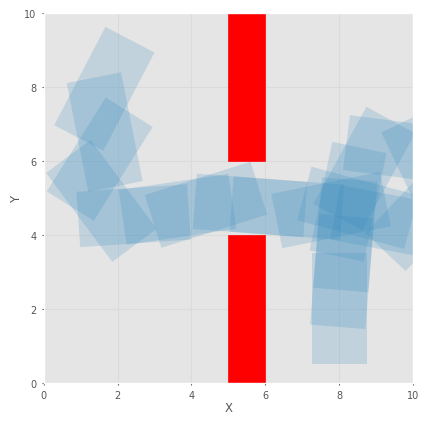

In [22]:
from roboticstoolbox import VehiclePolygon

va = VehiclePolygon(piano)
map.plot(block=None)
for i in np.unique(np.rint(np.linspace(0, len(path) - 1, 20)).astype(int)):
    va.plot(path[i, :], alpha=0.2)


## Pose-graph optimization

loaded TORO/LAGO format file: 1941 vertices, 3995 edges


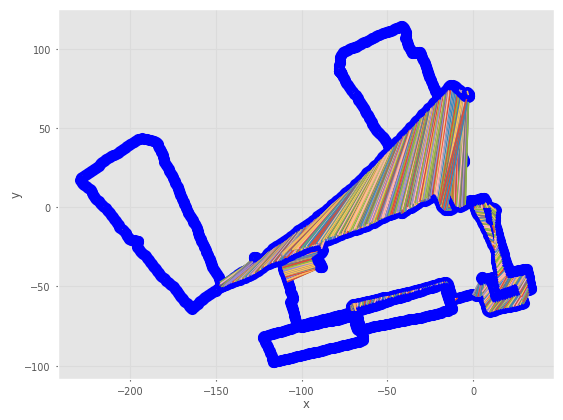

In [23]:
from roboticstoolbox import PoseGraph

pg = PoseGraph('data/killian-small.toro')

pg.plot(text=False, block=None)


done in 389.70 msec.  Total cost 1.78135e+06
done in 515.55 msec.  Total cost 1.39949e+06
done in 328.64 msec.  Total cost 36.678
done in 391.73 msec.  Total cost 5.44579
done in 427.14 msec.  Total cost 5.44565
done in 321.76 msec.  Total cost 5.44567


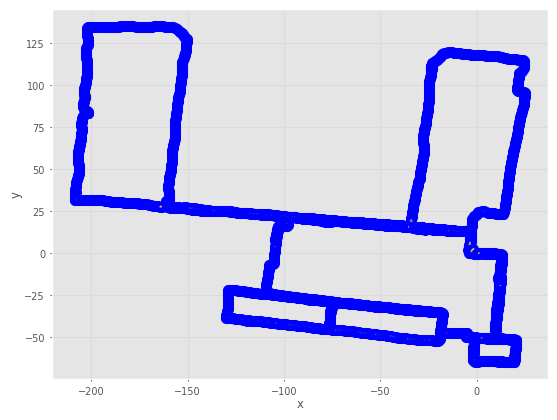

In [24]:

pg.optimize()

pg.plot(text=False, block=None)


# Arm robotics

In [25]:
from roboticstoolbox import models

panda = models.DH.Panda()

print(panda)

DHRobot: Panda (by Franka Emika), 7 joints (RRRRRRR), dynamics, geometry, modified DH parameters
┌─────────┬────────┬─────┬───────┬─────────┬────────┐
│  aⱼ₋₁   │  ⍺ⱼ₋₁  │ θⱼ  │  dⱼ   │   q⁻    │   q⁺   │
├─────────┼────────┼─────┼───────┼─────────┼────────┤
│     0.0 │   0.0° │  q1 │ 0.333 │ -166.0° │ 166.0° │
│     0.0 │ -90.0° │  q2 │   0.0 │ -101.0° │ 101.0° │
│     0.0 │  90.0° │  q3 │ 0.316 │ -166.0° │ 166.0° │
│  0.0825 │  90.0° │  q4 │   0.0 │ -176.0° │  -4.0° │
│ -0.0825 │ -90.0° │  q5 │ 0.384 │ -166.0° │ 166.0° │
│     0.0 │  90.0° │  q6 │   0.0 │   -1.0° │ 215.0° │
│   0.088 │  90.0° │  q7 │ 0.107 │ -166.0° │ 166.0° │
└─────────┴────────┴─────┴───────┴─────────┴────────┘

┌──────┬───────────────────────────────────────┐
│ tool │ t = 0, 0, 0.1; rpy/xyz = -45°, 0°, 0° │
└──────┴───────────────────────────────────────┘

┌──────┬─────┬────────┬─────┬───────┬─────┬───────┬──────┐
│ name │ q0  │ q1     │ q2  │ q3    │ q4  │ q5    │ q6   │
├──────┼─────┼────────┼─────┼───────┼─────

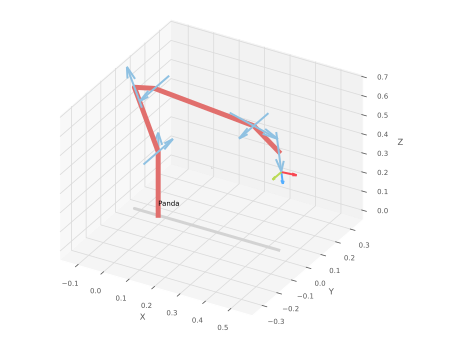

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'Panda')

In [26]:
q = panda.qr

panda.plot(q)

In [27]:
panda.fkine(q)

   0.995     0         0.09983   0.484     
   0        -1         0         0         
   0.09983   0        -0.995     0.413     
   0         0         0         1         


In [28]:
from spatialmath import SE3

sol = panda.ikine_QP(SE3.Trans(0.5, 0.2, 0.5) * SE3.Rx(math.pi) )
print(sol)

IKSolution: q=[0.9684, -0.07733, -0.5608, -1.703, -0.04119, 1.638, 1.197], success=True, iterations=42, searches=2, residual=2.01e-08


In [29]:
q = sol.q
panda.fkine(q)

   1         1.166e-07  1.039e-06  0.5       
   1.166e-07 -1         1.115e-07  0.2       
   1.039e-06 -1.115e-07 -1         0.5       
   0         0         0         1         


In [30]:
from roboticstoolbox import jtraj

tg = jtraj(panda.qz, panda.qr, 100)
print(tg)

Trajectory created by jtraj: 100 time steps x 7 axes


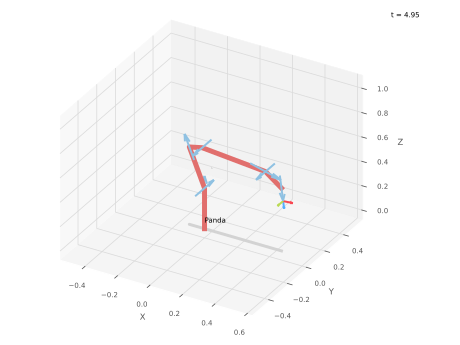

PyPlot3D backend, t = 4.99999999999999, scene:
  robot: Text(0.0, 0.0, 'Panda')

In [31]:
panda.plot(tg.q)

In [32]:
from roboticstoolbox import models

panda = models.ETS.Panda()
panda

ERobot: Panda (by Franka Emika), 7 joints (RRRRRRR)
┌──────┬───────┬───────┬────────┬─────────────────────────────────────────────┐
│ link │ link  │ joint │ parent │             ETS: parent to link             │
├──────┼───────┼───────┼────────┼─────────────────────────────────────────────┤
│    0 │ link0 │     0 │ BASE   │ tz(0.333) ⊕ Rz(q0)                          │
│    1 │ link1 │     1 │ link0  │ Rx(-90°) ⊕ Rz(q1)                           │
│    2 │ link2 │     2 │ link1  │ Rx(90°) ⊕ tz(0.316) ⊕ Rz(q2)                │
│    3 │ link3 │     3 │ link2  │ tx(0.0825) ⊕ Rx(90°) ⊕ Rz(q3)               │
│    4 │ link4 │     4 │ link3  │ tx(-0.0825) ⊕ Rx(-90°) ⊕ tz(0.384) ⊕ Rz(q4) │
│    5 │ link5 │     5 │ link4  │ Rx(90°) ⊕ Rz(q5)                            │
│    6 │ link6 │     6 │ link5  │ tx(0.088) ⊕ Rx(90°) ⊕ tz(0.107) ⊕ Rz(q6)    │
│    7 │ @ee   │       │ link6  │ tz(0.103) ⊕ Rz(-45°)                        │
└──────┴───────┴───────┴────────┴───────────────────────────────────

In [33]:
ets = panda.ets()
print(ets)

tz(0.333) ⊕ Rz(q0) ⊕ Rx(-90°) ⊕ Rz(q1) ⊕ Rx(90°) ⊕ tz(0.316) ⊕ Rz(q2) ⊕ tx(0.0825) ⊕ Rx(90°) ⊕ Rz(q3) ⊕ tx(-0.0825) ⊕ Rx(-90°) ⊕ tz(0.384) ⊕ Rz(q4) ⊕ Rx(90°) ⊕ Rz(q5) ⊕ tx(0.088) ⊕ Rx(90°) ⊕ tz(0.107) ⊕ Rz(q6) ⊕ tz(0.103) ⊕ Rz(-45°)


In [34]:
from roboticstoolbox import Robot

r = Robot(ets)
print(r)

ERobot: , 7 joints (RRRRRRR)
┌──────┬────────┬───────┬────────┬─────────────────────────────────────────────┐
│ link │  link  │ joint │ parent │             ETS: parent to link             │
├──────┼────────┼───────┼────────┼─────────────────────────────────────────────┤
│    0 │ link0  │     0 │ BASE   │ tz(0.333) ⊕ Rz(q0)                          │
│    1 │ link1  │     1 │ link0  │ Rx(-90°) ⊕ Rz(q1)                           │
│    2 │ link2  │     2 │ link1  │ Rx(90°) ⊕ tz(0.316) ⊕ Rz(q2)                │
│    3 │ link3  │     3 │ link2  │ tx(0.0825) ⊕ Rx(90°) ⊕ Rz(q3)               │
│    4 │ link4  │     4 │ link3  │ tx(-0.0825) ⊕ Rx(-90°) ⊕ tz(0.384) ⊕ Rz(q4) │
│    5 │ link5  │     5 │ link4  │ Rx(90°) ⊕ Rz(q5)                            │
│    6 │ link6  │     6 │ link5  │ tx(0.088) ⊕ Rx(90°) ⊕ tz(0.107) ⊕ Rz(q6)    │
│    7 │ @link7 │       │ link6  │ tz(0.103) ⊕ Rz(-45°)                        │
└──────┴────────┴───────┴────────┴─────────────────────────────────────────────┘

In [35]:
panda.fkine(q)

   1         1.166e-07  1.039e-06  0.5       
   1.166e-07 -1         1.115e-07  0.2       
   1.039e-06 -1.115e-07 -1         0.5       
   0         0         0         1         


In [36]:
panda.jacob0(panda.qr)

array([[       0,     0.08,        0,    0.246,        0,      0.2,        0],
       [   0.484,        0,    0.486,        0,    0.154,        0,        0],
       [       0,   -0.484,        0,    0.499,        0,    0.109,        0],
       [       0,        0,   -0.296,        0,    0.946,        0,   0.0998],
       [       0,        1,        0,       -1,        0,       -1,        0],
       [       1,        0,    0.955,        0,   -0.323,        0,   -0.995]])

In [37]:
panda.manipulability(panda.qr)

np.float64(0.08375150968113347)

In [38]:
panda.jacobe(q)

array([[    -0.2,   0.0946,    -0.21,    0.148,  -0.0815,    0.192,        0],
       [    -0.5,   -0.138,   -0.506,  -0.0429,   -0.187,   -0.084,        0],
       [-1.52e-07,    0.448,  -0.0231,   -0.476,        0,   -0.088,        0],
       [1.04e-06,   -0.824,  -0.0438,    0.397,    0.914,      0.4,        0],
       [-1.12e-07,   -0.567,   0.0637,    0.917,   -0.399,    0.916,        0],
       [      -1, -7.93e-07,   -0.997,   0.0411,   0.0669,        0,        1]])

In [39]:
H = panda.hessian0(q)
H.shape

(7, 6, 7)

In [40]:
panda.hasgeometry

False

In [41]:
panda = models.URDF.Panda()
panda

ERobot: panda (by Franka Emika), 7 joints (RRRRRRR), 1 gripper, geometry, collision
┌──────┬──────────────┬───────┬─────────────┬────────────────────────────────────────────────┐
│ link │     link     │ joint │   parent    │              ETS: parent to link               │
├──────┼──────────────┼───────┼─────────────┼────────────────────────────────────────────────┤
│    0 │ panda_link0  │       │ BASE        │ SE3()                                          │
│    1 │ panda_link1  │     0 │ panda_link0 │ SE3(0, 0, 0.333) ⊕ Rz(q0)                      │
│    2 │ panda_link2  │     1 │ panda_link1 │ SE3(-90°, -0°, 0°) ⊕ Rz(q1)                    │
│    3 │ panda_link3  │     2 │ panda_link2 │ SE3(0, -0.316, 0; 90°, -0°, 0°) ⊕ Rz(q2)       │
│    4 │ panda_link4  │     3 │ panda_link3 │ SE3(0.0825, 0, 0; 90°, -0°, 0°) ⊕ Rz(q3)       │
│    5 │ panda_link5  │     4 │ panda_link4 │ SE3(-0.0825, 0.384, 0; -90°, -0°, 0°) ⊕ Rz(q4) │
│    6 │ panda_link6  │     5 │ panda_link5 │ SE3(90°, -0°, 0

In [42]:
# panda.plot(q, backend="swift")

In [43]:
panda.hasgeometry

True

In [44]:
panda.hasdynamics

False

In [45]:
puma = models.DH.Puma560()
print(puma)

DHRobot: Puma 560 (by Unimation), 6 joints (RRRRRR), dynamics, geometry, standard DH parameters
┌─────┬────────┬────────┬────────┬─────────┬────────┐
│ θⱼ  │   dⱼ   │   aⱼ   │   ⍺ⱼ   │   q⁻    │   q⁺   │
├─────┼────────┼────────┼────────┼─────────┼────────┤
│  q1 │ 0.6718 │      0 │  90.0° │ -160.0° │ 160.0° │
│  q2 │      0 │ 0.4318 │   0.0° │ -110.0° │ 110.0° │
│  q3 │   0.15 │ 0.0203 │ -90.0° │ -135.0° │ 135.0° │
│  q4 │ 0.4318 │      0 │  90.0° │ -266.0° │ 266.0° │
│  q5 │      0 │      0 │ -90.0° │ -100.0° │ 100.0° │
│  q6 │      0 │      0 │   0.0° │ -266.0° │ 266.0° │
└─────┴────────┴────────┴────────┴─────────┴────────┘

┌──────┬─────┬──────┬───────┬─────┬──────┬─────┐
│ name │ q0  │ q1   │ q2    │ q3  │ q4   │ q5  │
├──────┼─────┼──────┼───────┼─────┼──────┼─────┤
│   qr │  0° │  90° │ -90°  │  0° │  0°  │  0° │
│   qz │  0° │  0°  │  0°   │  0° │  0°  │  0° │
│   qn │  0° │  45° │  180° │  0° │  45° │  0° │
│   qs │  0° │  0°  │ -90°  │  0° │  0°  │  0° │
└──────┴─────┴──────

In [46]:
puma.dynamics()

┌───────┬───────┬─────────────────────────┬────────────────────────────────────────┬──────────┬───────────┬───────────────────┬───────┐
│   j   │   m   │            r            │                   I                    │    Jm    │     B     │        Tc         │   G   │
├───────┼───────┼─────────────────────────┼────────────────────────────────────────┼──────────┼───────────┼───────────────────┼───────┤
│ link1 │  0    │  0,  0,  0              │  0,  0.35,  0,  0,  0,  0              │  0.0002  │  0.00148  │  0.395, -0.435    │ -62.6 │
│ link2 │  17.4 │ -0.364,  0.006,  0.228  │  0.13,  0.524,  0.539,  0,  0,  0      │  0.0002  │  0.000817 │  0.126, -0.071    │  108  │
│ link3 │  4.8  │ -0.0203, -0.0141,  0.07 │  0.066,  0.086,  0.0125,  0,  0,  0    │  0.0002  │  0.00138  │  0.132, -0.105    │ -53.7 │
│ link4 │  0.82 │  0,  0.019,  0          │  0.0018,  0.0013,  0.0018,  0,  0,  0  │  3.3e-05 │  7.12e-05 │  0.0112, -0.0169  │  76   │
│ link5 │  0.34 │  0,  0,  0              │  0.0

In [47]:
q = puma.qn

puma.inertia(q)

array([[    3.66,   -0.404,    0.101, -0.00252,        0,        0],
       [  -0.404,     4.41,    0.351,        0,  0.00236,        0],
       [   0.101,    0.351,    0.938,        0,  0.00148,        0],
       [-0.00252,        0,        0,    0.193,        0, 2.83e-05],
       [       0,  0.00236,  0.00148,        0,    0.171,        0],
       [       0,        0,        0, 2.83e-05,        0,    0.194]])

In [48]:
puma.gravload(q)

array([       0,     31.6,     6.04,        0,   0.0283,        0])

In [49]:
puma.coriolis(q, [1, 0, 0, 0,0, 0])

array([[       0,   -0.628,    0.361, 0.000306,        0,        0],
       [   0.628,        0,        0, -0.000586,        0,   -2e-05],
       [  -0.361,        0,        0, 3.58e-05,        0,   -2e-05],
       [-0.000306, 0.000586, -3.58e-05,        0, 0.000156,        0],
       [       0,        0,        0, -0.000156,        0,   -2e-05],
       [       0,    2e-05,    2e-05,        0,    2e-05,        0]])

In [50]:
puma.inertia_x(q)

array([[    17.3,    -2.75,    -9.62,        0,     0.28,        0],
       [   -2.75,     11.6,     1.25, 6.71e-05,  -0.0703, 6.71e-05],
       [   -9.62,     1.25,     13.3,        0,    0.277,        0],
       [       0, 6.71e-05,        0,    0.194,        0,    0.194],
       [    0.28,  -0.0703,    0.277,        0,    0.171,        0],
       [       0, 6.71e-05,        0,    0.194,        0,    0.194]])

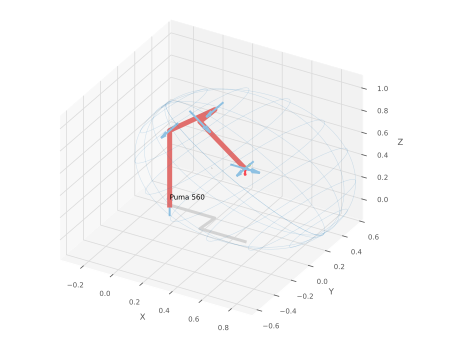

In [51]:
puma.plot(q, backend="pyplot")
puma.fellipse(q)

In [52]:
puma.gravload_x(q)

array([   -30.1,     7.58,     53.7,        0,  -0.0283,        0])